C:\Users\jhona\anaconda3\envs\obspy_env\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\jhona\anaconda3\envs\obspy_env\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\jhona\anaconda3\envs\obspy_env\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


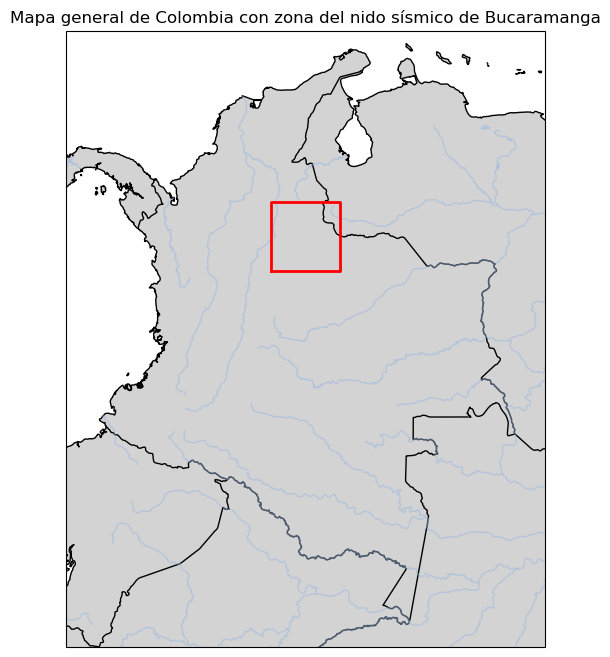

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Crear mapa general de Colombia
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extensión aproximada de Colombia
ax.set_extent([-80, -66, -5, 13])

# Agregar límites políticos y relieve básico
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, alpha=0.5)

# Rectángulo que marca el área del nido sísmico de Bucaramanga
x0, x1, y0, y1 = -74, -72, 6, 8
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color='red', linewidth=2)
plt.title("Mapa general de Colombia con zona del nido sísmico de Bucaramanga", fontsize=12)
plt.show()


6 Event(s) in Catalog:
2025-04-18T10:31:44.347000Z |  +6.709,  -73.089 | 5.2  mb
2024-01-21T17:19:48.378000Z |  +6.759,  -73.026 | 5.2  mb
2023-09-14T07:01:04.008000Z |  +6.791,  -73.033 | 5.1  Mww
2023-05-28T15:45:57.185000Z |  +6.696,  -73.030 | 5.2  Mww
2023-03-10T09:18:40.646000Z |  +6.722,  -73.040 | 5.4  mww
2023-02-15T13:04:09.720000Z |  +6.766,  -73.024 | 5.2  mb


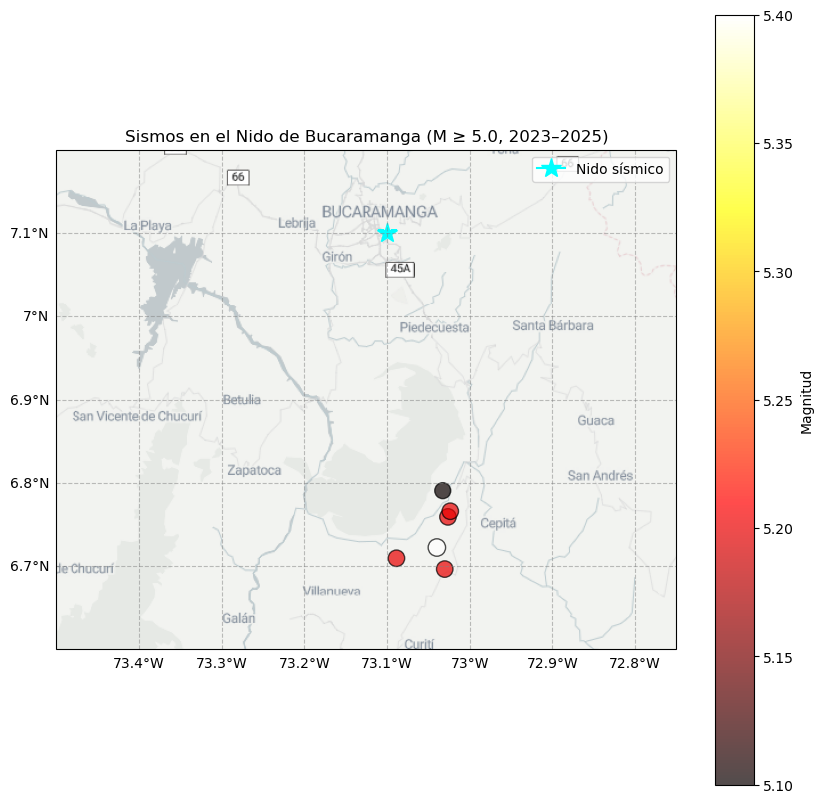

In [13]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

# --- Configuración del cliente y rango de búsqueda ---
client = Client("IRIS")

starttime = UTCDateTime("2023-01-01")
endtime = UTCDateTime("2025-10-01")

lat0, lat1 = 6.5, 7.5
lon0, lon1 = -74.5, -72.5

# --- Descargar catálogo de sismos ---
cat = client.get_events(starttime=starttime, endtime=endtime,
                        minlatitude=lat0, maxlatitude=lat1,
                        minlongitude=lon0, maxlongitude=lon1,
                        minmagnitude=5.0)

print(cat)  # Muestra resumen en consola

# --- Extraer latitudes, longitudes y magnitudes ---
lats = [ev.preferred_origin() or ev.origins[0] for ev in cat]
lons = [o.longitude for o in lats]
lats = [o.latitude for o in lats]
mags = [ev.preferred_magnitude() or ev.magnitudes[0] for ev in cat]
mags = [m.mag for m in mags]

# --- Mapa con Stadia Maps ---
API_KEY = "ddd7c374-821f-4ebd-ba92-e3cc25a2cff8"
tiles = cimgt.StadiaMapsTiles(style='alidade_smooth', apikey=API_KEY)

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=tiles.crs)
ax.set_extent([-73.5, -72.75, 6.6, 7.2], crs=ccrs.PlateCarree())
ax.add_image(tiles, 10)

# --- Añadir los sismos ---
sc = ax.scatter(lons, lats, c=mags, cmap="hot", s=[m**3 for m in mags],
                transform=ccrs.PlateCarree(), alpha=0.7, edgecolor='k')

# --- Marcar el nido sísmico ---
ax.plot(-73.1, 7.1, marker='*', color='cyan', markersize=15,
        transform=ccrs.PlateCarree(), label='Nido sísmico')

# --- Configuración del mapa ---
gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
plt.colorbar(sc, ax=ax, label="Magnitud")

plt.legend()
plt.title("Sismos en el Nido de Bucaramanga (M ≥ 5.0, 2023–2025)")
plt.show()


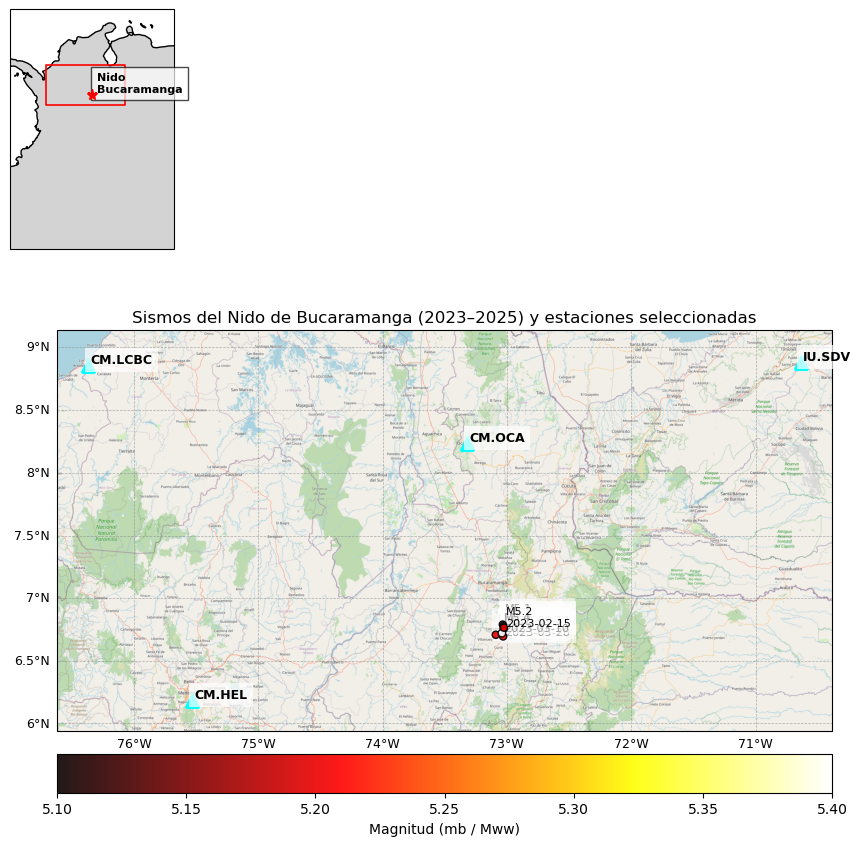

In [9]:
# Mapa principal + inset de Colombia (OpenStreetMap tiles)
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import cartopy.feature as cfeature
from cartopy.feature import ShapelyFeature
from shapely.geometry import box
import numpy as np

client = Client("IRIS")

# --- Eventos dados (time, lat, lon, mag) ---
events = [
    ("2025-04-18T10:31:44.347000Z", 6.709, -73.089, 5.2),
    ("2024-01-21T17:19:48.378000Z", 6.759, -73.026, 5.2),
    ("2023-09-14T07:01:04.008000Z", 6.791, -73.033, 5.1),
    ("2023-05-28T15:45:57.185000Z", 6.696, -73.030, 5.2),
    ("2023-03-10T09:18:40.646000Z", 6.722, -73.040, 5.4),
    ("2023-02-15T13:04:09.720000Z", 6.766, -73.024, 5.2),
]

# --- Estaciones requeridas (network, station) ---
stations_req = [("CM", "HEL"), ("IU", "SDV"), ("CM", "OCA"), ("CM", "LCBC")]

# --- Extraer coordenadas de eventos ---
ev_lats = [ev[1] for ev in events]
ev_lons = [ev[2] for ev in events]
ev_mags = [ev[3] for ev in events]

# --- Obtener coordenadas de las estaciones desde IRIS ---
station_coords = []
for net, sta in stations_req:
    try:
        inv = client.get_stations(network=net, station=sta, level="station")
        st0 = inv[0][0]   # primer resultado
        station_coords.append((net, sta, st0.latitude, st0.longitude))
    except Exception as e:
        print(f"⚠ No se obtuvo {net}.{sta}: {e}")

# Si alguna estación no se encontró, puedes agregar coords manualmente:
# station_coords.append(("CM","HEL", LAT, LON))

# --- Preparar extents automáticos usando todos los puntos (eventos + estaciones) ---
all_lats = list(ev_lats) + [s[2] for s in station_coords]
all_lons = list(ev_lons) + [s[3] for s in station_coords]

# Si falta alguna estación, esto evita error
if len(all_lats) == 0 or len(all_lons) == 0:
    raise RuntimeError("No se encontraron coordenadas de eventos/estaciones.")

margin = 0.25  # grados de margen; aumenta si aún queda estación fuera
lon_min, lon_max = min(all_lons) - margin, max(all_lons) + margin
lat_min, lat_max = min(all_lats) - margin, max(all_lats) + margin

# --- Tile source (OpenStreetMap - sin API key) ---
tiles = cimgt.OSM()

# --- Crear figura y ejes principales ---
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=tiles.crs)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_image(tiles, 9)  # zoom level (ajusta 8-12)

# --- Graficar eventos (tamaño por magnitud, color por magnitud) ---
sizes = [ (m**2) * 1 for m in ev_mags ]  # escala visual; ajusta si quieres
sc = ax.scatter(ev_lons, ev_lats, c=ev_mags, cmap="hot", s=sizes,
                transform=ccrs.PlateCarree(), edgecolor='k', zorder=5, alpha=0.9)
for (t, lat, lon, mag) in events:
    ax.text(lon + 0.015, lat + 0.01, f"M{mag:.1f}\n{t[:10]}", transform=ccrs.PlateCarree(),
            fontsize=8, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# --- Graficar estaciones ---
for net, sta, lat, lon in station_coords:
    ax.plot(lon, lat, marker="^", color="cyan", markersize=10,
            transform=ccrs.PlateCarree(), zorder=6)
    ax.text(lon + 0.015, lat + 0.01, f"{net}.{sta}", transform=ccrs.PlateCarree(),
            fontsize=9, fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), zorder=7)

# --- Gridlines y detalles ---
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.03)
cbar.set_label("Magnitud (mb / Mww)")

plt.title("Sismos del Nido de Bucaramanga (2023–2025) y estaciones seleccionadas", fontsize=12)

# --- Crear inset (mapa de Colombia) en la esquina superior izquierda ---
# extent aproximado de Colombia
col_lon_min, col_lon_max = -79.5, -66.5
col_lat_min, col_lat_max = -5.5, 13.5

left, bottom, width, height = 0.02, 0.73, 0.28, 0.24  # posición del inset en fracciones [0..1]
axins = fig.add_axes([left, bottom, width, height], projection=ccrs.PlateCarree())
axins.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray')
axins.add_feature(cfeature.COASTLINE.with_scale('50m'))
axins.set_extent([col_lon_min, col_lon_max, col_lat_min, col_lat_max], crs=ccrs.PlateCarree())

# marcar el nido en el inset (usar promedio de eventos)
nido_lon = np.mean(ev_lons)
nido_lat = np.mean(ev_lats)
axins.plot(nido_lon, nido_lat, marker='*', color='red', markersize=8,
           transform=ccrs.PlateCarree(), zorder=6)
axins.text(nido_lon + 0.4, nido_lat + 0.2, "Nido\nBucaramanga", transform=ccrs.PlateCarree(),
           fontsize=8, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

# dibujar rectángulo que marca la extensión del mapa principal (en inset)
try:
    region_box = box(lon_min, lat_min, lon_max, lat_max)
    feat = ShapelyFeature([region_box], ccrs.PlateCarree(), edgecolor='red', facecolor='none', linewidth=1.2)
    axins.add_feature(feat)
except Exception:
    # Si falla shapely, traza una línea simple con plot
    axins.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
               [lat_min, lat_min, lat_max, lat_max, lat_min],
               color='red', linewidth=1.0, transform=ccrs.PlateCarree())

# descargar mapa 
plt.savefig("Mapa_de_sismos_y_estaciones.jpg", dpi=1200, bbox_inches='tight')
plt.show()


In [14]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy import Stream

client = Client("IRIS")

# Lista de eventos
events = [
    ("2025-04-18T10:31:44", 6.709, -73.089, 5.2),
    ("2024-01-21T17:19:48", 6.759, -73.026, 5.2),
    ("2023-09-14T07:01:04", 6.791, -73.033, 5.1),
    ("2023-05-28T15:45:57", 6.696, -73.030, 5.2),
    ("2023-03-10T09:18:40", 6.722, -73.040, 5.4),
    ("2023-02-15T13:04:09", 6.766, -73.024, 5.2),
]

# Estación ejemplo (podemos cambiar luego)
network = "IU"    # Red global
station = "COLA"  # Estación de referencia en Colombia
channel = "BH?"   # Banda ancha
location = "*"

st_all = Stream()

for time_str, lat, lon, mag in events:
    origin_time = UTCDateTime(time_str)

    try:
        st = client.get_waveforms(network=network, station=station,
                                  location=location, channel=channel,
                                  starttime=origin_time - 60,
                                  endtime=origin_time + 300)
        print(f"✓ Descargado evento {time_str} ({mag} Mw)")

        # Procesamiento básico
        st.detrend("linear")
        st.filter("bandpass", freqmin=0.5, freqmax=10)
        st_all += st

    except Exception as e:
        print(f"⚠ No se pudo descargar {time_str}: {e}")

# Guarda todo en un archivo local
st_all.write("sismogramas_bucaramanga.mseed", format="MSEED")
print("Archivo guardado como sismogramas_bucaramanga.mseed")


✓ Descargado evento 2025-04-18T10:31:44 (5.2 Mw)
✓ Descargado evento 2024-01-21T17:19:48 (5.2 Mw)
✓ Descargado evento 2023-09-14T07:01:04 (5.1 Mw)
✓ Descargado evento 2023-05-28T15:45:57 (5.2 Mw)
✓ Descargado evento 2023-03-10T09:18:40 (5.4 Mw)
✓ Descargado evento 2023-02-15T13:04:09 (5.2 Mw)
Archivo guardado como sismogramas_bucaramanga.mseed


C:\Users\jhona\anaconda3\envs\obspy_env\lib\site-packages\obspy\io\mseed\core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


In [ ]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import os

client = Client("IRIS")

# Carpeta donde guardar las imágenes
os.makedirs("sismogramas_jpg", exist_ok=True)

# Lista de eventos (tiempo, lat, lon, magnitud)
events = [
    ("2025-04-18T10:31:44", 6.709, -73.089, 5.2),
    ("2024-01-21T17:19:48", 6.759, -73.026, 5.2),
    ("2023-09-14T07:01:04", 6.791, -73.033, 5.1),
    ("2023-05-28T15:45:57", 6.696, -73.030, 5.2),
    ("2023-03-10T09:18:40", 6.722, -73.040, 5.4),
    ("2023-02-15T13:04:09", 6.766, -73.024, 5.2),
]

for i, (time_str, lat, lon, mag) in enumerate(events, 1):
    origin_time = UTCDateTime(time_str)
    print(f"\n🔹 Evento {i}: {time_str}  |  M={mag}")

    # Buscar estaciones cercanas (≤ 5° de radio)
    inv = client.get_stations(latitude=lat, longitude=lon,
                              maxradius=5, channel="BH?", level="channel")

    for net in inv:
        for sta in net:
            station = sta.code
            network = net.code

            try:
                st = client.get_waveforms(network=network, station=station,
                                          location="*", channel="BH?",
                                          starttime=origin_time - 60,
                                          endtime=origin_time + 240)

                st.detrend("linear")
                st.filter("bandpass", freqmin=0.5, freqmax=10)

                # --- Graficar
                fig, ax = plt.subplots(figsize=(10, 4))
                for tr in st:
                    ax.plot(tr.times("relative"), tr.data, label=f"{tr.id}")

                ax.set_title(f"Evento {i} - {time_str}\n"
                             f"{network}.{station}  |  Magnitud {mag}")
                ax.set_xlabel("Tiempo (s)")
                ax.set_ylabel("Amplitud")
                ax.legend(loc="upper right", fontsize=8)
                plt.tight_layout()

                # --- Guardar como imagen
                filename = f"sismogramas_jpg/{i}_{network}_{station}.jpg"
                plt.savefig(filename, dpi=150)
                plt.close(fig)
                print(f"✓ Guardado: {filename}")

                # Solo una estación por evento para no saturar
                break

            except Exception as e:
                print(f"⚠ No se pudo descargar de {network}.{station}: {e}")
                continue

            break  # Quitar esta monda si toca intentar más estaciones


In [8]:
# === Descarga y guarda los WAV de las dos estaciones especificadas ===
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import numpy as np
from scipy.io.wavfile import write
import scipy.signal as sig

client = Client("IRIS")

# --- Evento ---
event_time = UTCDateTime("2023-02-15T13:04:09")
lat, lon, mag = 6.766, -73.024, 5.2

# --- Ventana de tiempo (5 min antes, 1 h después) ---
t0 = event_time - 300
t1 = event_time + 3600

# --- Estaciones específicas ---
stations = [("CM", "HEL"), ("IU", "SDV")]

for net, sta in stations:
    try:
        print(f"\nDescargando {net}.{sta} ...")
        st = client.get_waveforms(
            network=net, station=sta, location="*", channel="BHZ",
            starttime=t0, endtime=t1
        )
        print(f" Descargado {net}.{sta}")

        # --- Selecciona el primer trazo ---
        tr = st[0].copy()
        tr.trim(starttime=event_time, endtime=event_time + 300)  # 5 minutos
        tr.filter("bandpass", freqmin=0.5, freqmax=8.0)

        # --- Acelerar 100× (compresión temporal) ---
        factor = 1
        data = tr.data.astype(np.float32)
        n_new = int(len(data) / factor)
        data_fast = sig.resample(data, n_new)

        # --- Normalización segura ---
        amp = np.max(np.abs(data_fast))
        if amp < 1e-9:
            print(f" {net}.{sta} casi sin señal, no se normaliza.")
            data_fast[:] = 0
        else:
            data_fast /= amp

        # --- Reescalar a 48 kHz (audio estándar) ---
        target_sr = 48000
        data_audio = sig.resample(data_fast, int(len(data_fast) * (target_sr / tr.stats.sampling_rate)))

        # --- Guardar como WAV ---
        filename = f"6_{net}_{sta}_Bucaramanga2025_1min.wav"
        write(filename, target_sr, (data_audio * 32767).astype(np.int16))
        print(f" Guardado {filename} dur ≈ 1 min")

    except Exception as e:
        print(f" Error con {net}.{sta}: {e}")

print("\n Proceso completado.")



Descargando CM.HEL ...
 Descargado CM.HEL
 Guardado 6_CM_HEL_Bucaramanga2025_1min.wav dur ≈ 1 min

Descargando IU.SDV ...
 Descargado IU.SDV
 Guardado 6_IU_SDV_Bucaramanga2025_1min.wav dur ≈ 1 min

 Proceso completado.


Tasa de muestreo: 48000 Hz, Duración: 13.86 s


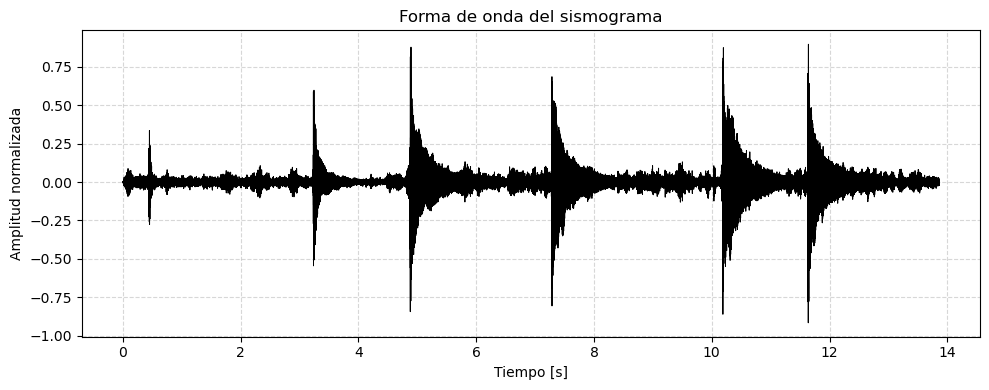

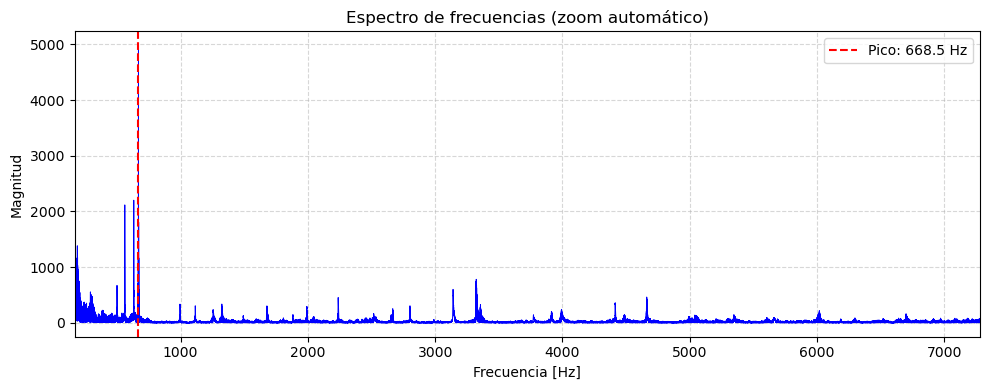

Rango de zoom: 168.1–7280.7 Hz
Frecuencia dominante: 668.47 Hz
Frecuencias dominantes y notas aproximadas:
668.5 Hz → E5
631.6 Hz → D#5
561.1 Hz → C#5
669.9 Hz → E5
188.2 Hz → F#3
189.0 Hz → F#3
667.1 Hz → E5
189.9 Hz → F#3
186.5 Hz → F#3
670.6 Hz → E5


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks

# --- 1. Cargar el audio ---
fs, data = wavfile.read("cadencia en mi.wav")
data = data.astype(float)
data = data / np.max(np.abs(data))  # normalizar

print(f"Tasa de muestreo: {fs} Hz, Duración: {len(data)/fs:.2f} s")

# === Convertir a mono si tiene dos canales ===
if data.ndim > 1:
    data = data.mean(axis=1)

# --- 2. Forma de onda ---
t = np.linspace(0, len(data)/fs, len(data))
plt.figure(figsize=(10, 4))
plt.plot(t, data, color="black", linewidth=0.7)
plt.title("Forma de onda del sismograma")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud normalizada")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 3. FFT y espectro ---
N = len(data)
fft_vals = np.fft.rfft(data)
fft_freq = np.fft.rfftfreq(N, d=1/fs)
magnitude = np.abs(fft_vals)

# --- Encontrar frecuencia dominante ---
peak_idx = np.argmax(magnitude)
peak_freq = fft_freq[peak_idx]

# --- Calcular rango de energía (zoom automático) ---
energy = magnitude**2
cumulative = np.cumsum(energy) / np.sum(energy)
low_limit = fft_freq[np.searchsorted(cumulative, 0.025)]
high_limit = fft_freq[np.searchsorted(cumulative, 0.975)]

# --- Gráfico con zoom automático ---
plt.figure(figsize=(10, 4))
plt.plot(fft_freq, magnitude, color="blue", linewidth=0.7)
plt.axvline(peak_freq, color="red", linestyle="--", label=f"Pico: {peak_freq:.1f} Hz")
plt.title("Espectro de frecuencias (zoom automático)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(low_limit, high_limit)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rango de zoom: {low_limit:.1f}–{high_limit:.1f} Hz")
print(f"Frecuencia dominante: {peak_freq:.2f} Hz")

# --- 4. Frecuencias dominantes y notas ---
def freq_to_note(freq):
    if freq <= 0:
        return None
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    A4 = 440.0
    semitones = 12 * np.log2(freq / A4)
    midi = int(round(semitones)) + 69
    note_name = note_names[midi % 12] + str(midi // 12 - 1)
    return note_name

# Encontrar picos locales con una distancia mínima entre ellos (ej. 10 bins) para evitar tomar la misma cresta
peaks, _ = find_peaks(magnitude, distance=10)

# Ordenar los picos encontrados por su magnitud de mayor a menor
sorted_peaks = peaks[np.argsort(magnitude[peaks])][::-1]

# Tomar los principales
top_indices = sorted_peaks[:10]
dominant_freqs = fft_freq[top_indices]
dominant_notes = [freq_to_note(f) for f in dominant_freqs]

print("Frecuencias dominantes y notas aproximadas:")
for f, n in zip(dominant_freqs, dominant_notes):
    print(f"{f:.1f} Hz → {n}")